# Імпорт датасету та бібліотек

In [1]:
!pip install imgkit
!apt-get update
!which wkhtmltoimage
!apt-get install -y wkhtmltopdf
!pip install adjustText

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,389 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,816 kB]
Get:14 http://security.ubu

Mounted at /content/drive


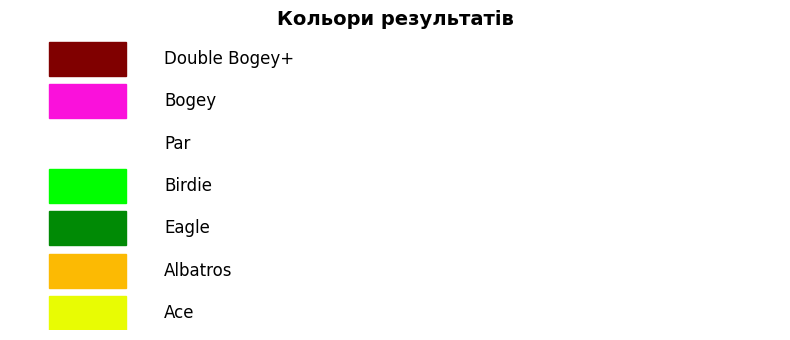

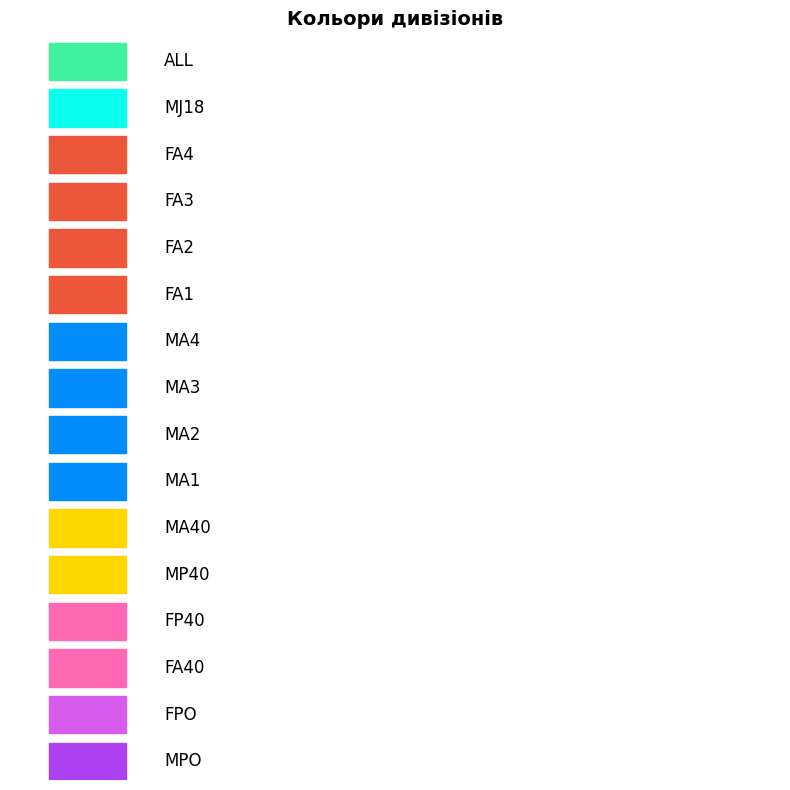

,Тип,Значення,Сума
0,par,"[3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 3, 4, 3, 4, 4, ...",60
1,o_par,"[3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 3, 4, 3, 4, 4, ...",61


In [2]:

import pandas as pd
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from google.colab import drive
from IPython.display import display, HTML
import os
import imgkit
from PIL import Image  # 📷 Постобробка PNG

# warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/dg/2025/Lutsk Open/tab.xlsx'
df = pd.read_excel(file_path)
# Приводимо всі назви колонок до типу str
df.columns = df.columns.map(str)

year = "2025"
tournament = "Lutsk Open"
# Приводимо всі числові колонки до типу int (цілі числа)
for col in df.select_dtypes(include=['float', 'int']).columns:
    df[col] = df[col].fillna(0).astype(int)

# Скидання індексу до стандартного вигляду
df = df.reset_index(drop=True)

o_par = []
par = [] # mpo



holes = [str(i) for i in range(1, 19)]

# Вибір рядків, де Round == 'Par' і DIV == 'MPO'
par_rows = df[(df['Round'] == 'PAR') & (df['DIV'] == 'MPO')]
par_values = par_rows[[str(i) for i in range(1, 19)]].values.tolist()
par = [int(val) for sublist in par_values for val in sublist]

# Аналогічно для DIV == 'ALL'
o_par_rows = df[(df['Round'] == 'PAR') & (df['DIV'] == 'ALL')]
o_par_values = o_par_rows[[str(i) for i in range(1, 19)]].values.tolist()
o_par = [int(val) for sublist in o_par_values for val in sublist]

if not par:
    par = o_par


# Сума для обчислення Score
par_sum = sum(par)
o_par_sum = sum(o_par)

if not par_sum:
    par_sum = o_par_sum

df = df[df['Round'] != 'PAR']

# 🎨 Кольори результатів
score_colors = {
    'Ace': '#e8fc03',
    'Albatros': '#fcba03',
    'Eagle': '#008A05',
    'Birdie': '#00FF00',
    'Par': '#FFFFFF',
    'Bogey': '#fa11db',
    'Double Bogey+': '#800000'
}

# 🎨 Кольори дивізіонів
division_colors = {
    'MPO': '#ae41f2',
    'FPO': '#d55ced',

    'FA40': '#FF69B4',
    'FP40': '#FF69B4',

    'MP40': '#FFD700',
    'MA40': '#FFD700',

    'MA1': '#038cfc',
    'MA2': '#038cfc',
    'MA3': '#038cfc',
    'MA4': '#038cfc',

    'FA1': '#ec5739',
    'FA2': '#ec5739',
    'FA3': '#ec5739',
    'FA4': '#ec5739',

    'MJ18':'#0affef',
    'ALL': '#41f29d'
}
division_list = list(df['DIV'].unique())

def plot_color_legend(color_dict, title):
    fig, ax = plt.subplots(figsize=(8, len(color_dict) * 0.5))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, len(color_dict))
    ax.axis('off')
    for i, (label, color) in enumerate(color_dict.items()):
        ax.add_patch(plt.Rectangle((0.05, i), 0.1, 0.8, color=color))
        ax.text(0.2, i + 0.4, label, va='center', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 🔹 Візуалізація кольорів для результатів
plot_color_legend(score_colors, 'Кольори результатів')

# 🔸 Візуалізація кольорів для дивізіонів
plot_color_legend(division_colors, 'Кольори дивізіонів')

from IPython.display import display, HTML

# Створюємо DataFrame для відображення
par_table = pd.DataFrame({
    'Тип': ['par', 'o_par'],
    'Значення': [str(par), str(o_par)],
    'Сума': [par_sum, o_par_sum]
})
df = df[df['Thru'] == 'F']
df = df[df['Round'] != 'PAR']
# Виводимо з HTML-заголовком
display(HTML("<h3 style='color:#444;'>📊 Порівняння масивів PAR</h3>"))
display(par_table)

# Аналіз раунду

## Style

In [3]:
holes = [str(i) for i in range(1, 19)]
# 🎨 Стилізація рядка
def style_row(row):
    styles = [f'background-color: {division_colors.get(row["DIV"], "#B8860B")}'] * 2
    for i, hole in enumerate(holes):
        score, par_val = row[hole], par[i]
        if score == 1:
            color = score_colors['Ace']
        elif score == par_val - 2 and par_val > 3:
            color = score_colors['Eagle']
        elif score == par_val - 1:
            color = score_colors['Birdie']
        elif score == par_val - 3:
            color = score_colors['Albatros']
        elif score == par_val:
            color = score_colors['Par']
        elif score == par_val + 1:
            color = score_colors['Bogey']
        else:
            color = score_colors['Double Bogey+']
        styles.append(f'background-color: {color}')
 # 🖍️ Білий текст для Tot і Score
    styles += ['background-color: #222; color: white;', 'background-color: #222; color: white;']
    return styles

# 🖌️ Стиль таблиці
def apply_table_style(styler):
    return styler.set_table_styles([
        {'selector': 'th', 'props': [('background-color', 'black'), ('color', 'white'), ('text-align', 'center'), ('border', '1px solid black')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black')]}
    ]).set_properties(**{'color': 'black', 'border-color': 'black'})

In [4]:
from IPython.display import display, HTML

# 🧹 Копія df без 'Round' і 'Thru'
df_clean = df.drop(columns=['Round', 'Thru']).copy()

# ➕ Додаємо Tot і Score
df_clean['Tot'] = df_clean[holes].sum(axis=1)
df_clean['Score'] = df_clean.apply(
    lambda row: row['Tot'] - 60 if row['DIV'] == 'MPO' else row['Tot'] - 61,
    axis=1
)

# 🔢 Індексація з 1
df_clean.index = range(1, len(df_clean) + 1)

# 🖌️ Стилізація всієї таблиці
styled_df = df_clean.style.apply(style_row, axis=1)

styled_df = styled_df.set_table_styles([
    {'selector': 'th', 'props': [
        ('background-color', 'black'),
        ('color', 'white'),
        ('text-align', 'center'),
        ('border', '1px solid black')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'),
        ('border', '1px solid black')
    ]}
]).set_properties(**{
    'color': 'black',
    'border-color': 'black'
})

# 📊 Відображення
display(HTML("<h3 style='color:#444;'>📋 Повна таблиця всіх дивізіонів</h3>"))
display(styled_df)


,Player,DIV,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,Tot,Score
1,Bohdan Aleksieiev,MPO,3,3,2,3,3,3,3,3,3,4,2,4,2,3,5,2,3,4,55,-5
2,Bohdan Aleksieiev,MPO,3,3,3,3,2,4,3,3,4,3,3,3,2,3,4,3,4,3,56,-4
3,Bohdan Aleksieiev,MPO,4,3,2,3,2,3,3,3,3,3,3,4,3,3,4,2,3,4,55,-5
4,Oleksandr Ratushniak,MPO,4,3,2,3,2,3,3,3,4,2,3,6,2,3,4,3,4,4,58,-2
5,Oleksandr Ratushniak,MPO,2,3,2,3,3,3,2,2,6,3,3,3,3,5,6,3,6,4,62,2
6,Oleksandr Ratushniak,MPO,2,3,2,4,2,3,3,3,4,3,3,3,2,3,4,2,4,3,53,-7
7,Ruvym Muts,MPO,3,2,2,3,3,2,3,3,4,5,5,3,2,5,3,3,4,3,58,-2
8,Ruvym Muts,MPO,3,4,4,2,2,2,3,2,4,2,2,3,3,3,5,2,4,5,55,-5
9,Ruvym Muts,MPO,4,3,3,3,3,3,4,3,3,2,4,3,3,6,4,3,5,4,63,3
10,Oleksandr Romanenko,MPO,3,4,3,3,2,3,3,3,5,2,3,5,3,4,3,3,4,3,59,-1


## Ideal

In [5]:
# 🧼 Перетворення значень лунок у числовий тип
# 🧼 Перетворення значень лунок у числовий тип int
df[holes] = df[holes].apply(pd.to_numeric, errors='coerce').astype('Int64')


# 🧮 Ідеальні результати
ideal_rounds = df.groupby(['Player', 'DIV'])[holes].min().reset_index()
ideal_rounds['Tot'] = ideal_rounds[holes].sum(axis=1)

# Динамічне віднімання залежно від дивізіону
def calculate_score(row):
    return row['Tot'] - (par_sum if row['DIV'] == 'MPO' else o_par_sum)

ideal_rounds['Score'] = ideal_rounds.apply(calculate_score, axis=1)
ideal_rounds_sorted = ideal_rounds.sort_values(by='Tot').reset_index(drop=True)
ideal_rounds_sorted.index += 1

# 📋 Загальна таблиця
styled_ideal = apply_table_style(ideal_rounds_sorted.style.apply(style_row, axis=1))
display(HTML("<h3 style='color:#444;'>🏆 Загальна таблиця (усі дивізіони)</h3>"))
display(styled_ideal)

# 📌 Таблиці по дивізіонах
for div in ideal_rounds_sorted['DIV'].unique():
    div_df = ideal_rounds_sorted[ideal_rounds_sorted['DIV'] == div].reset_index(drop=True)
    div_df.index += 1
    styled_div = apply_table_style(div_df.style.apply(style_row, axis=1))
    display(HTML(f"<h3 style='color:#444;'>🏅 Дивізіон: {div}</h3>"))
    display(styled_div)


,Player,DIV,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,Tot,Score
1,Ruvym Muts,MPO,3,2,2,2,2,2,3,2,3,2,2,3,2,3,3,2,4,3,45,-15
2,Oleksandr Romanenko,MPO,2,3,3,2,2,2,3,2,3,2,2,3,2,3,3,3,3,3,46,-14
3,Oleksandr Ratushniak,MPO,2,3,2,3,2,3,2,2,4,2,3,3,2,3,4,2,4,3,49,-11
4,Artur Zhuravliov,MPO,3,2,2,2,2,3,2,2,4,2,3,3,3,3,4,3,3,4,50,-10
5,Bohdan Aleksieiev,MPO,3,3,2,3,2,3,3,3,3,3,2,3,2,3,4,2,3,3,50,-10
6,Oleksandr Lapchuk,MPO,2,3,3,2,2,2,2,2,4,2,2,5,2,4,3,3,4,4,51,-9
7,Dima Boiko,MPO,2,2,3,2,2,3,3,3,3,3,3,3,2,3,4,2,5,3,51,-9
8,Ruslan Muts,MPO,2,3,2,3,2,3,3,2,4,2,3,4,2,3,4,3,3,4,52,-8
9,Vadym Novikov,MPO,2,3,2,3,3,3,2,3,4,3,3,3,2,4,5,3,3,4,55,-5
10,Anton Baidiuk,MA4,3,2,3,4,3,3,3,3,4,2,4,4,2,5,4,2,4,4,59,-2


,Player,DIV,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,Tot,Score
1,Ruvym Muts,MPO,3,2,2,2,2,2,3,2,3,2,2,3,2,3,3,2,4,3,45,-15
2,Oleksandr Romanenko,MPO,2,3,3,2,2,2,3,2,3,2,2,3,2,3,3,3,3,3,46,-14
3,Oleksandr Ratushniak,MPO,2,3,2,3,2,3,2,2,4,2,3,3,2,3,4,2,4,3,49,-11
4,Artur Zhuravliov,MPO,3,2,2,2,2,3,2,2,4,2,3,3,3,3,4,3,3,4,50,-10
5,Bohdan Aleksieiev,MPO,3,3,2,3,2,3,3,3,3,3,2,3,2,3,4,2,3,3,50,-10
6,Oleksandr Lapchuk,MPO,2,3,3,2,2,2,2,2,4,2,2,5,2,4,3,3,4,4,51,-9
7,Dima Boiko,MPO,2,2,3,2,2,3,3,3,3,3,3,3,2,3,4,2,5,3,51,-9
8,Ruslan Muts,MPO,2,3,2,3,2,3,3,2,4,2,3,4,2,3,4,3,3,4,52,-8
9,Vadym Novikov,MPO,2,3,2,3,3,3,2,3,4,3,3,3,2,4,5,3,3,4,55,-5


,Player,DIV,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,Tot,Score
1,Anton Baidiuk,MA4,3,2,3,4,3,3,3,3,4,2,4,4,2,5,4,2,4,4,59,-2
2,Vitalii Nykytiuk,MA4,3,3,4,3,3,3,3,3,4,3,4,5,2,4,4,3,5,4,63,2
3,Ivan Golub,MA4,3,3,3,4,3,4,3,3,5,3,4,4,2,4,5,3,4,5,65,4
4,Nazarii Bocheliuk,MA4,5,3,3,4,2,3,3,3,6,3,3,5,2,5,5,3,4,6,68,7


,Player,DIV,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,Tot,Score
1,Viktoria Muts,FPO,2,4,3,4,3,4,3,3,6,3,4,5,2,4,5,2,3,6,66,5


,Player,DIV,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,Tot,Score
1,Anastasiia Golub,FA3,3,4,3,3,3,3,3,3,4,2,4,6,3,4,4,3,5,6,66,5
2,Anna Novikova,FA3,4,4,4,3,3,4,4,3,5,4,4,5,3,5,5,4,5,4,73,12
3,Bohdana Muts,FA3,4,5,4,4,4,4,3,3,6,4,5,7,2,6,7,4,5,6,83,22


## Horror

In [6]:
# 🧮 Побудова найгірших раундів
horror_rounds = df.groupby(['Player', 'DIV'])[holes].max().reset_index()
horror_rounds['Tot'] = horror_rounds[holes].sum(axis=1)

# Динамічне віднімання залежно від дивізіону
def calculate_horror_score(row):
    return row['Tot'] - (par_sum if row['DIV'] == 'MPO' else o_par_sum)

horror_rounds['Score'] = horror_rounds.apply(calculate_horror_score, axis=1)
horror_rounds_sorted = horror_rounds.sort_values(by='Tot').reset_index(drop=True)
horror_rounds_sorted.index += 1

# 📊 Загальна таблиця
styled_horror_ALL = apply_table_style(horror_rounds_sorted.style.apply(style_row, axis=1))
display(HTML("<h3 style='color:#444;'>💩 Загальна таблиця найгірших результатів (усі дивізіони)</h3>"))
display(styled_horror_ALL)

# 📦 Таблиці по дивізіонах
for div in horror_rounds_sorted['DIV'].unique():
    div_df = horror_rounds_sorted[horror_rounds_sorted['DIV'] == div].reset_index(drop=True)
    div_df.index += 1
    styled_div = apply_table_style(div_df.style.apply(style_row, axis=1))
    display(HTML(f"<h3 style='color:#444;'>💩 Найгірші результати – {div}</h3>"))
    display(styled_div)


,Player,DIV,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,Tot,Score
1,Bohdan Aleksieiev,MPO,4,3,3,3,3,4,3,3,4,4,3,4,3,3,5,3,4,4,63,3
2,Oleksandr Lapchuk,MPO,3,3,4,3,2,4,3,3,4,3,4,5,4,6,4,3,4,5,67,7
3,Oleksandr Ratushniak,MPO,4,3,2,4,3,3,3,3,6,3,3,6,3,5,6,3,6,4,70,10
4,Oleksandr Romanenko,MPO,4,4,3,3,3,4,4,3,5,4,3,5,4,4,6,3,4,4,70,10
5,Ruvym Muts,MPO,4,4,4,3,3,3,4,3,4,5,5,3,3,6,5,3,5,5,72,12
6,Artur Zhuravliov,MPO,4,4,3,4,3,3,3,3,5,3,5,4,5,4,6,3,4,6,72,12
7,Vadym Novikov,MPO,4,4,2,4,4,4,4,3,6,4,4,6,3,5,5,4,4,5,75,15
8,Dima Boiko,MPO,3,3,3,3,3,3,4,4,5,5,4,5,5,5,6,4,5,7,77,17
9,Ruslan Muts,MPO,4,4,3,3,4,3,3,4,7,5,5,5,4,4,6,4,4,7,79,19
10,Vitalii Nykytiuk,MA4,4,3,4,4,4,4,3,3,6,4,5,7,3,5,5,4,6,7,81,20


,Player,DIV,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,Tot,Score
1,Bohdan Aleksieiev,MPO,4,3,3,3,3,4,3,3,4,4,3,4,3,3,5,3,4,4,63,3
2,Oleksandr Lapchuk,MPO,3,3,4,3,2,4,3,3,4,3,4,5,4,6,4,3,4,5,67,7
3,Oleksandr Ratushniak,MPO,4,3,2,4,3,3,3,3,6,3,3,6,3,5,6,3,6,4,70,10
4,Oleksandr Romanenko,MPO,4,4,3,3,3,4,4,3,5,4,3,5,4,4,6,3,4,4,70,10
5,Ruvym Muts,MPO,4,4,4,3,3,3,4,3,4,5,5,3,3,6,5,3,5,5,72,12
6,Artur Zhuravliov,MPO,4,4,3,4,3,3,3,3,5,3,5,4,5,4,6,3,4,6,72,12
7,Vadym Novikov,MPO,4,4,2,4,4,4,4,3,6,4,4,6,3,5,5,4,4,5,75,15
8,Dima Boiko,MPO,3,3,3,3,3,3,4,4,5,5,4,5,5,5,6,4,5,7,77,17
9,Ruslan Muts,MPO,4,4,3,3,4,3,3,4,7,5,5,5,4,4,6,4,4,7,79,19


,Player,DIV,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,Tot,Score
1,Vitalii Nykytiuk,MA4,4,3,4,4,4,4,3,3,6,4,5,7,3,5,5,4,6,7,81,20
2,Ivan Golub,MA4,4,5,5,4,4,4,3,5,6,4,5,6,3,5,5,4,6,6,84,23
3,Anton Baidiuk,MA4,4,3,6,5,3,4,4,4,6,4,5,7,3,6,7,5,6,8,90,29
4,Nazarii Bocheliuk,MA4,7,6,5,5,4,4,5,5,7,4,4,7,4,6,7,7,6,7,100,39


,Player,DIV,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,Tot,Score
1,Viktoria Muts,FPO,4,5,4,4,4,5,3,4,6,5,5,6,3,5,6,4,5,7,85,24


,Player,DIV,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,Tot,Score
1,Anastasiia Golub,FA3,5,4,6,4,4,4,4,5,8,4,5,6,4,5,6,4,6,8,92,31
2,Anna Novikova,FA3,5,6,5,4,4,5,4,4,6,4,6,6,4,6,6,4,6,8,93,32
3,Bohdana Muts,FA3,5,6,5,5,4,5,6,5,9,6,6,8,5,7,7,5,6,8,108,47


## Best

In [7]:
# 🧮 Найкращі реальні результати
best_real_sorted = (
    df.loc[df.groupby('Player')['Tot'].idxmin()]
    .reset_index(drop=True)
)

# Динамічне віднімання залежно від дивізіону
def calculate_best_score(row):
    return row['Tot'] - (par_sum if row['DIV'] == 'MPO' else o_par_sum)

best_real_sorted['Score'] = best_real_sorted.apply(calculate_best_score, axis=1)
best_real_sorted = best_real_sorted.sort_values(by='Tot').reset_index(drop=True)
best_real_sorted.index += 1
best_real_sorted = best_real_sorted[['Player', 'DIV'] + holes + ['Tot', 'Score']]
styled_best_real_ALL = apply_table_style(best_real_sorted.style.apply(style_row, axis=1))
display(HTML("<h3 style='color:#444;'>🌟 Найкращі реальні результати (усі дивізіони)</h3>"))
display(styled_best_real_ALL)

for div in best_real_sorted['DIV'].unique():
    div_df = best_real_sorted[best_real_sorted['DIV'] == div].reset_index(drop=True)
    div_df.index += 1
    styled_div = apply_table_style(div_df.style.apply(style_row, axis=1))
    display(HTML(f"<h3 style='color:#444;'>🌟 Найкращі реальні результати – {div}</h3>"))
    display(styled_div)


,Player,DIV,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,Tot,Score
1,Oleksandr Ratushniak,MPO,2,3,2,4,2,3,3,3,4,3,3,3,2,3,4,2,4,3,53,-7
2,Bohdan Aleksieiev,MPO,3,3,2,3,3,3,3,3,3,4,2,4,2,3,5,2,3,4,55,-5
3,Oleksandr Romanenko,MPO,2,3,3,2,3,4,3,2,5,4,2,3,2,3,4,3,3,4,55,-5
4,Ruvym Muts,MPO,3,4,4,2,2,2,3,2,4,2,2,3,3,3,5,2,4,5,55,-5
5,Oleksandr Lapchuk,MPO,2,3,3,2,2,3,2,2,4,2,2,5,4,4,4,3,4,5,56,-4
6,Artur Zhuravliov,MPO,3,2,3,4,2,3,2,3,5,2,4,3,3,3,4,3,4,4,57,-3
7,Ruslan Muts,MPO,2,3,3,3,2,3,3,2,4,2,5,4,2,4,6,3,4,4,59,-1
8,Vadym Novikov,MPO,2,3,2,3,3,3,2,3,4,3,3,6,2,5,5,3,3,5,60,0
9,Anton Baidiuk,MA4,3,2,3,4,3,3,3,3,6,3,4,4,2,5,6,2,4,4,64,3
10,Dima Boiko,MPO,2,2,3,3,3,3,3,4,3,5,4,3,4,4,6,4,5,3,64,4


,Player,DIV,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,Tot,Score
1,Oleksandr Ratushniak,MPO,2,3,2,4,2,3,3,3,4,3,3,3,2,3,4,2,4,3,53,-7
2,Bohdan Aleksieiev,MPO,3,3,2,3,3,3,3,3,3,4,2,4,2,3,5,2,3,4,55,-5
3,Oleksandr Romanenko,MPO,2,3,3,2,3,4,3,2,5,4,2,3,2,3,4,3,3,4,55,-5
4,Ruvym Muts,MPO,3,4,4,2,2,2,3,2,4,2,2,3,3,3,5,2,4,5,55,-5
5,Oleksandr Lapchuk,MPO,2,3,3,2,2,3,2,2,4,2,2,5,4,4,4,3,4,5,56,-4
6,Artur Zhuravliov,MPO,3,2,3,4,2,3,2,3,5,2,4,3,3,3,4,3,4,4,57,-3
7,Ruslan Muts,MPO,2,3,3,3,2,3,3,2,4,2,5,4,2,4,6,3,4,4,59,-1
8,Vadym Novikov,MPO,2,3,2,3,3,3,2,3,4,3,3,6,2,5,5,3,3,5,60,0
9,Dima Boiko,MPO,2,2,3,3,3,3,3,4,3,5,4,3,4,4,6,4,5,3,64,4


,Player,DIV,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,Tot,Score
1,Anton Baidiuk,MA4,3,2,3,4,3,3,3,3,6,3,4,4,2,5,6,2,4,4,64,3
2,Vitalii Nykytiuk,MA4,3,3,4,4,3,3,3,3,4,3,4,6,2,5,4,3,5,7,69,8
3,Ivan Golub,MA4,3,3,3,4,3,4,3,4,6,3,4,6,3,4,5,4,6,5,73,12
4,Nazarii Bocheliuk,MA4,5,4,5,4,2,4,3,3,7,4,4,7,3,5,6,4,4,6,80,19


,Player,DIV,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,Tot,Score
1,Anastasiia Golub,FA3,4,4,3,3,3,4,3,4,4,2,5,6,4,4,5,3,5,7,73,12
2,Anna Novikova,FA3,5,4,4,4,3,5,4,3,5,4,4,5,4,6,6,4,6,4,80,19
3,Bohdana Muts,FA3,5,5,4,4,4,5,3,5,9,5,5,7,5,6,7,5,6,6,96,35


,Player,DIV,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,Tot,Score
1,Viktoria Muts,FPO,2,4,4,4,4,4,3,4,6,3,4,6,2,4,5,4,5,6,74,13


## Worst

In [8]:
# 🧮 Найгірші реальні результати
worst_real_sorted = (
    df.loc[df.groupby('Player')['Tot'].idxmax()]
    .reset_index(drop=True)
)

# Динамічне віднімання залежно від дивізіону
def calculate_worst_real_score(row):
    return row['Tot'] - (par_sum if row['DIV'] == 'MPO' else o_par_sum)

worst_real_sorted['Score'] = worst_real_sorted.apply(calculate_worst_real_score, axis=1)
worst_real_sorted = worst_real_sorted.sort_values(by='Tot').reset_index(drop=True)
worst_real_sorted.index += 1
worst_real_sorted = worst_real_sorted[['Player', 'DIV'] + holes + ['Tot', 'Score']]
# 📊 Загальна таблиця
styled_worst_real_ALL = apply_table_style(worst_real_sorted.style.apply(style_row, axis=1))
display(HTML("<h3 style='color:#444;'>🕳️ Найгірші реальні результати (усі дивізіони)</h3>"))
display(styled_worst_real_ALL)

# 📦 Таблиці по дивізіонах
for div in worst_real_sorted['DIV'].unique():
    div_df = worst_real_sorted[worst_real_sorted['DIV'] == div].reset_index(drop=True)
    div_df.index += 1
    styled_div = apply_table_style(div_df.style.apply(style_row, axis=1))
    display(HTML(f"<h3 style='color:#444;'>🕳️ Найгірші реальні результати – {div}</h3>"))
    display(styled_div)


,Player,DIV,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,Tot,Score
1,Bohdan Aleksieiev,MPO,3,3,3,3,2,4,3,3,4,3,3,3,2,3,4,3,4,3,56,-4
2,Oleksandr Romanenko,MPO,4,3,3,2,3,2,4,3,3,3,2,4,4,4,6,3,3,4,60,0
3,Oleksandr Lapchuk,MPO,3,3,4,3,2,4,3,3,4,3,3,5,2,6,3,3,4,4,62,2
4,Artur Zhuravliov,MPO,3,3,2,2,2,3,3,3,5,2,3,3,5,4,6,3,4,6,62,2
5,Oleksandr Ratushniak,MPO,2,3,2,3,3,3,2,2,6,3,3,3,3,5,6,3,6,4,62,2
6,Ruvym Muts,MPO,4,3,3,3,3,3,4,3,3,2,4,3,3,6,4,3,5,4,63,3
7,Dima Boiko,MPO,3,3,3,3,2,3,4,4,5,5,3,5,5,5,4,2,5,4,68,8
8,Vadym Novikov,MPO,4,4,2,4,3,3,3,3,6,4,4,5,2,4,5,4,4,4,68,8
9,Ruslan Muts,MPO,4,3,3,3,4,3,3,4,7,5,3,5,3,4,4,3,4,7,72,12
10,Vitalii Nykytiuk,MA4,4,3,4,3,4,4,3,3,5,3,5,5,3,4,5,4,5,6,73,12


,Player,DIV,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,Tot,Score
1,Bohdan Aleksieiev,MPO,3,3,3,3,2,4,3,3,4,3,3,3,2,3,4,3,4,3,56,-4
2,Oleksandr Romanenko,MPO,4,3,3,2,3,2,4,3,3,3,2,4,4,4,6,3,3,4,60,0
3,Oleksandr Lapchuk,MPO,3,3,4,3,2,4,3,3,4,3,3,5,2,6,3,3,4,4,62,2
4,Artur Zhuravliov,MPO,3,3,2,2,2,3,3,3,5,2,3,3,5,4,6,3,4,6,62,2
5,Oleksandr Ratushniak,MPO,2,3,2,3,3,3,2,2,6,3,3,3,3,5,6,3,6,4,62,2
6,Ruvym Muts,MPO,4,3,3,3,3,3,4,3,3,2,4,3,3,6,4,3,5,4,63,3
7,Dima Boiko,MPO,3,3,3,3,2,3,4,4,5,5,3,5,5,5,4,2,5,4,68,8
8,Vadym Novikov,MPO,4,4,2,4,3,3,3,3,6,4,4,5,2,4,5,4,4,4,68,8
9,Ruslan Muts,MPO,4,3,3,3,4,3,3,4,7,5,3,5,3,4,4,3,4,7,72,12


,Player,DIV,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,Tot,Score
1,Vitalii Nykytiuk,MA4,4,3,4,3,4,4,3,3,5,3,5,5,3,4,5,4,5,6,73,12
2,Ivan Golub,MA4,4,5,5,4,4,4,3,5,6,3,5,4,3,4,5,3,4,6,77,16
3,Anton Baidiuk,MA4,4,3,6,4,3,3,4,4,6,4,4,7,2,5,7,5,6,8,85,24
4,Nazarii Bocheliuk,MA4,6,6,5,4,4,3,4,5,7,3,3,6,4,6,7,3,5,7,88,27


,Player,DIV,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,Tot,Score
1,Viktoria Muts,FPO,4,4,3,4,3,5,3,3,6,5,4,5,3,5,6,2,4,7,76,15


,Player,DIV,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,Tot,Score
1,Anastasiia Golub,FA3,3,4,6,3,3,3,4,3,8,4,4,6,3,4,6,4,6,8,82,21
2,Anna Novikova,FA3,5,4,5,3,4,4,4,3,6,4,5,6,4,5,6,4,5,8,85,24
3,Bohdana Muts,FA3,4,5,5,5,4,4,4,5,8,4,5,7,5,7,7,5,6,8,98,37


## Export

In [9]:
# ⚙️ Конфігурація wkhtmltoimage

imgkit_config = imgkit.config(wkhtmltoimage='/usr/bin/wkhtmltoimage')  # ✅ об'єкт конфігурації
render_options = {
    'format': 'png',
    'encoding': 'UTF-8',
    'zoom': 2,
    'width': 1000
}

# 🌑 CSS для темної теми
css = '''
body {
    background-color: black;
    margin: 0;
    padding: 20px;
}
th, td {
    font-size: 13px;
    font-weight: bold;
    border: 0.5px solid #555;
    padding: 4px;
}
'''

# 🧱 Функція генерації PNG
def generate_player_png(row, filename, crop_right):
    player = row['Player']
    div = row['DIV']
    base_path = f"/content/drive/MyDrive/dg/{year}/{tournament}/{div}"
    player_folder = os.path.join(base_path, player)
    os.makedirs(player_folder, exist_ok=True)

    file_path = os.path.join(player_folder, filename)
    player_df = pd.DataFrame([row]).reset_index(drop=True)

    styled = player_df.style.apply(style_row, axis=1).set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', 'black'),
            ('color', 'white'),
            ('text-align', 'center'),
            ('border', '0.5px solid #555'),
            ('padding', '4px'),
            ('font-size', '13px'),
            ('font-weight', 'bold')
        ]},
        {'selector': 'td', 'props': [
            ('text-align', 'center'),
            ('border', '0.5px solid #555'),
            ('padding', '4px'),
            ('font-size', '13px'),
            ('font-weight', 'bold')
        ]}
    ])

    html_str = f"<html><head><style>{css}</style></head><body>{styled.to_html()}</body></html>"

    imgkit.from_string(html_str, file_path, config=imgkit_config, options=render_options)

    with Image.open(file_path) as im:
        width, height = im.size
        cropped = im.crop((10, 10, width - crop_right, height - 10))
        cropped.save(file_path)

# 🔁 Обробка всіх типів раундів — правильна версія
round_configs = [
    {'df': ideal_rounds, 'filename': 'ideal.png', 'crop': 270},
    {'df': horror_rounds, 'filename': 'horror.png', 'crop': 250},
    {'df': worst_real_sorted, 'filename': 'worst.png', 'crop': 280},
    {'df': best_real_sorted, 'filename': 'best.png', 'crop': 270}
]


for config in round_configs:
    df = config['df']
    if isinstance(df, pd.DataFrame):
        for _, row in df.iterrows():
            generate_player_png(row, config['filename'], config['crop'])
    else:
        print(f"⚠️ Об'єкт {df} не є DataFrame. Пропускаю.")

def generate_table_png(df, filename, crop_right, div_name):
    base_path = f"/content/drive/MyDrive/dg/{year}/{tournament}/{div_name}"
    os.makedirs(base_path, exist_ok=True)

    file_path = os.path.join(base_path, filename)

    # 🔧 Стилізація через style_row — застосовується до всіх колонок
    styled = df.style.apply(style_row, axis=1).set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', 'black'),
            ('color', 'white'),
            ('text-align', 'center'),
            ('border', '0.5px solid #555'),
            ('padding', '4px'),
            ('font-size', '13px'),
            ('font-weight', 'bold')
        ]},
        {'selector': 'td', 'props': [
            ('text-align', 'center'),
            ('border', '0.5px solid #555'),
            ('padding', '4px'),
            ('font-size', '13px'),
            ('font-weight', 'bold')
        ]}
    ])

    html_str = f"<html><head><style>{css}</style></head><body>{styled.to_html()}</body></html>"
    imgkit.from_string(html_str, file_path, config=imgkit_config, options=render_options)

    with Image.open(file_path) as im:
        width, height = im.size
        cropped = im.crop((10, 10, width - crop_right, height - 10))
        cropped.save(file_path)


# 🔁 Обробка PNG для кожного гравця
for config in round_configs:
    df = config['df']
    if isinstance(df, pd.DataFrame):
        for _, row in df.iterrows():
            generate_player_png(row, config['filename'], config['crop'])

# 📊 Обробка PNG для кожного дивізіону
divisions = df['DIV'].unique()  # або сформуй список вручну, якщо df не містить всі дивізіони

for config in round_configs:
    df = config['df']
    if isinstance(df, pd.DataFrame):
        for div in divisions:
            div_df = (
                df[df['DIV'] == div]
                .sort_values(by='Tot', ascending=True)
                .reset_index(drop=True)
            )
            generate_table_png(div_df, config['filename'], 0, div)


for config in round_configs:
    df = config['df']
    if isinstance(df, pd.DataFrame):
        sorted_df = df.sort_values(by='Tot', ascending=True).reset_index(drop=True)
        generate_table_png(sorted_df, config['filename'], 0, 'ALL')

df = pd.read_excel(file_path)
df = df[df['Thru'] == 'F']
df = df[df['Round'] != 'PAR']

QStandardPaths: XDG_RUNTIME_DIR not set, defaulting to '/tmp/runtime-root'
Loading page (1/2)
Rendering (2/2)                                                    
Done                                                               
QStandardPaths: XDG_RUNTIME_DIR not set, defaulting to '/tmp/runtime-root'
Loading page (1/2)
Rendering (2/2)                                                    
Done                                                               
QStandardPaths: XDG_RUNTIME_DIR not set, defaulting to '/tmp/runtime-root'
Loading page (1/2)
Rendering (2/2)                                                    
Done                                                               
QStandardPaths: XDG_RUNTIME_DIR not set, defaulting to '/tmp/runtime-root'
Loading page (1/2)
Rendering (2/2)                                                    
Done                                                               
QStandardPaths: XDG_RUNTIME_DIR not set, defaulting to '/tmp/runtime-root'
Loadi

# Buskets

# Загальна функція

In [10]:
import os
#holes = list(range(1, 19))  # [1, 2, ..., 18]
holes = [str(i) for i in range(1, 19)]

def plot_division_pie_charts(filtered_df, par, holes, title, div_name, year, tournament):
    fig, axs = plt.subplots(3, 6, figsize=(20, 10), facecolor='#000000')
    axs = axs.flatten()

    for i, hole in enumerate(holes):
        ax = axs[i]
        scores = filtered_df[hole].astype(int)
        par_val = par[i]

        score_counts = {
            'Ace': (scores == 1).sum(),
            'Albatros': (scores == par_val - 3).sum(),
            'Eagle': ((scores == par_val - 2) & (par_val > 3)).sum(),
            'Birdie': (scores == par_val - 1).sum(),
            'Par': (scores == par_val).sum(),
            'Bogey': (scores == par_val + 1).sum(),
            'Double Bogey+': (scores >= par_val + 2).sum()
        }

        filtered_scores = {k: v for k, v in score_counts.items() if v > 0}
        values = list(filtered_scores.values())
        labels = list(filtered_scores.keys())
        used_colors = [score_colors[l] for l in labels]

        wedges, texts = ax.pie(
            values,
            colors=used_colors,
            startangle=90,
            wedgeprops=dict(width=0.5, edgecolor='black')
        )

        total = sum(values)
        for w, v in zip(wedges, values):
            angle = (w.theta2 + w.theta1) / 2
            x = 0.75 * np.cos(np.deg2rad(angle))
            y = 0.75 * np.sin(np.deg2rad(angle))
            pct = f'{(v / total) * 100:.0f}%'
            ax.text(x, y, pct, ha='center', va='center', color='black', fontsize=9, fontweight='bold')

        avg_score = scores.mean()
        ax.text(0, 0, f'{avg_score:.1f}', ha='center', va='center', color='white', fontsize=20, fontweight='bold')
        ax.set_title(f'Кошик {hole}\nPar {par_val}', color='white', fontsize=15)
        ax.set_aspect('equal')

    fig.suptitle(title, color='white', fontsize=18)

    legend_patches = [
        plt.Line2D([0], [0], marker='o', color='w', label=label,
                   markerfacecolor=score_colors[label], markersize=10)
        for label in score_colors if label in labels
    ]
    fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=12)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])

    # 📁 Створення директорії та збереження
    folder_path = f"/content/drive/MyDrive/dg/{year}/{tournament}/{div_name}"
    os.makedirs(folder_path, exist_ok=True)
    file_path = os.path.join(folder_path, f"holes_avg.png")
    fig.savefig(file_path, dpi=300, bbox_inches='tight', facecolor='#000000')
    plt.close(fig)


In [11]:

for div in division_list:
    current_par = par if div == 'MPO' else o_par

    plot_division_pie_charts(
        filtered_df=df[df['DIV'] == div],
        par=current_par,
        holes=holes,
        title=f'Розподіл результатів по лунках ({div})',
        div_name=div,
        year=year,
        tournament=tournament
    )


In [12]:
plot_division_pie_charts(
    filtered_df=df,
    par=par,
    holes=holes,
    title='Розподіл результатів по лунках (усі дивізіони)',
    div_name='ALL',
    year=year,
    tournament=tournament
)


In [13]:
def get_division_stats(df, par_list, holes):
    stats = {
        'Metric': ['Avg', 'Ace', 'Albatros', 'Eagle', 'Birdie', 'Par', 'Bogey', 'Dbl+']
    }

    for i, hole in enumerate(holes):
        if hole not in df.columns:
            continue

        scores = df[hole].dropna().astype(int)
        par_val = par_list[i]

        stats[f'Hole {hole}'] = [
            round(scores.mean(), 2),                         # Avg
            (scores == 1).sum(),                             # Ace
            (scores == par_val - 3).sum(),                   # Albatros
            ((scores == par_val - 2) & (par_val > 3)).sum(), # Eagle
            (scores == par_val - 1).sum(),                   # Birdie
            (scores == par_val).sum(),                       # Par
            (scores == par_val + 1).sum(),                   # Bogey
            (scores >= par_val + 2).sum()                    # Double Bogey+
        ]
    return pd.DataFrame(stats).set_index('Metric')
division_stats = []

for div in df['DIV'].unique():
    div_df = df[df['DIV'] == div]
    current_par = par if div == 'MPO' else o_par
    stats = get_division_stats(div_df, current_par, holes)
    stats.index = [f'{div} {i}' for i in stats.index]
    division_stats.append(stats)

full_table = pd.concat(division_stats)
display(HTML("<h3 style='color:#444;'>📊 Статистика по дивізіонах</h3>"))
display(full_table)


,Hole 1,Hole 2,Hole 3,Hole 4,Hole 5,Hole 6,Hole 7,Hole 8,Hole 9,Hole 10,Hole 11,Hole 12,Hole 13,Hole 14,Hole 15,Hole 16,Hole 17,Hole 18
MPO Avg,3.00,3.11,2.67,2.85,2.56,3.00,2.96,2.85,4.33,3.15,3.30,4.07,2.93,3.89,4.44,3.00,3.96,4.30
MPO Ace,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
MPO Albatros,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
MPO Eagle,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
MPO Birdie,8.00,3.00,11.00,8.00,14.00,4.00,5.00,7.00,5.00,8.00,5.00,11.00,11.00,11.00,4.00,5.00,7.00,5.00
MPO Par,11.00,18.00,14.00,15.00,11.00,19.00,18.00,17.00,12.00,11.00,12.00,5.00,9.00,10.00,12.00,17.00,15.00,14.00
MPO Bogey,8.00,6.00,2.00,4.00,2.00,4.00,4.00,3.00,7.00,4.00,7.00,9.00,5.00,4.00,6.00,5.00,4.00,5.00
MPO Dbl+,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,4.00,3.00,2.00,2.00,2.00,5.00,0.00,1.00,3.00
FPO Avg,3.33,4.33,3.33,4.00,3.67,4.33,3.00,3.67,6.00,4.00,4.33,5.67,2.33,4.33,5.67,3.00,4.00,6.33
FPO Ace,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [14]:
# 📊 Функція для обчислення середнього
def get_avg(df, par_list):
    return pd.Series([df[hole].astype(int).mean() for hole in holes], index=holes)

# 📐 Функція для обчислення відсотків
def compute_percent(avg, par):
    return (avg / par) * 100

# 📋 Збір середніх по всіх дивізіонах
avg_by_div = {}
for div in df['DIV'].unique():
    div_df = df[df['DIV'] == div]
    avg_by_div[div] = compute_percent(get_avg(div_df, par), par).round(1)

# 📊 Додавання загального середнього
avg_by_div['ALL'] = compute_percent(get_avg(df, par), par).round(1)

# 📦 Побудова таблиці
percent_table = pd.DataFrame(avg_by_div).T

# 📋 Вивід
display(percent_table)


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
MPO,100.0,103.7,88.9,95.1,85.2,100.0,98.8,95.1,108.3,104.9,109.9,101.9,97.5,97.2,111.1,100.0,99.1,107.4
FPO,111.1,144.4,111.1,133.3,122.2,144.4,100.0,122.2,150.0,133.3,144.4,141.7,77.8,108.3,141.7,100.0,100.0,158.3
FA3,148.1,155.6,144.4,125.9,122.2,140.7,129.6,129.6,163.9,133.3,163.0,158.3,125.9,133.3,147.2,137.0,136.1,172.2
MA4,136.1,119.4,136.1,136.1,111.1,122.2,113.9,119.4,141.7,108.3,138.9,139.6,88.9,120.8,131.2,125.0,122.9,145.8
ALL,117.6,119.0,111.1,112.4,100.0,115.0,107.8,108.5,128.4,112.4,128.1,123.0,99.3,109.8,124.0,112.4,111.3,130.9


In [15]:
for division in percent_table.index:
    sorted_percent = percent_table.loc[division].sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(12, 6), facecolor='black')

    # 🔢 Позиції по осі X
    x_pos = np.arange(len(sorted_percent))

    # 📊 Побудова барів
    bars = ax.bar(x_pos, sorted_percent.values, color=division_colors[division])

    # 🏷️ Підписи над барами
    for bar, value in zip(bars, sorted_percent.values):
        ax.text(bar.get_x() + bar.get_width()/2, value + 1,
                f'{value:.1f}%', ha='center', va='bottom', color='white', fontsize=9)

    # 💚 Лінія на 100%
    ax.axhline(100, color='lime', linestyle='--', linewidth=3)

    # 🧾 Підписи осі X
    ax.set_xticks(x_pos)
    ax.set_xticklabels(sorted_percent.index, color='white', fontsize=10)

    # 📌 Оформлення
    ax.set_title(f'Рейтинг складності лунок ({division})', color='white', fontsize=14)
    ax.set_xlabel('Лунка', color='white')
    ax.set_ylabel('% від par', color='white')
    ax.tick_params(colors='white')
    ax.set_facecolor('black')
    fig.patch.set_facecolor('black')
    ax.set_ylim(60, max(sorted_percent.values.max() + 10, 110))
    ax.grid(axis='y', linestyle='--', alpha=0.3, color='white')
    plt.tight_layout()

    # 📁 Збереження на диск
    folder_path = f"/content/drive/MyDrive/dg/{year}/{tournament}/{division}"
    os.makedirs(folder_path, exist_ok=True)
    file_path = os.path.join(folder_path, f"holes.png")
    fig.savefig(file_path, dpi=300, bbox_inches='tight', facecolor='black')
    plt.close(fig)


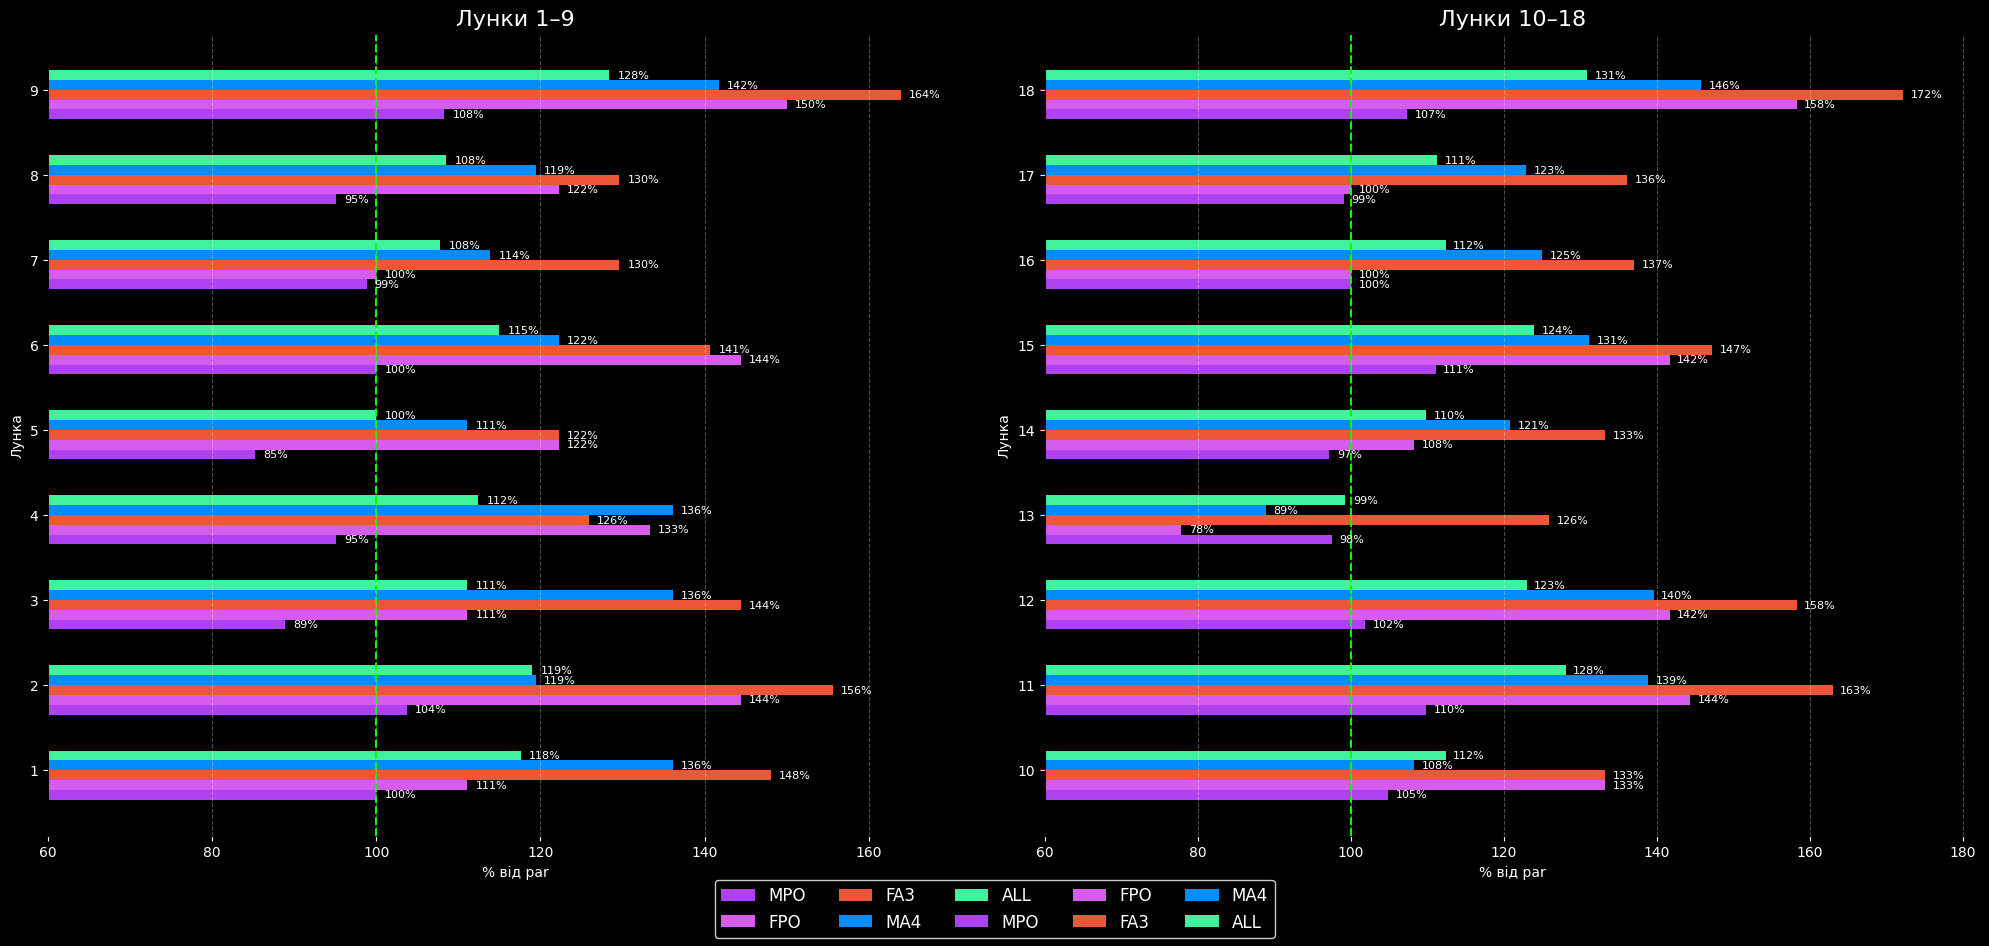

In [16]:
# 🔢 Дані
holes = [str(i) for i in range(1, 19)]
group1 = holes[:9]   # Лунки 1–9
group2 = holes[9:]   # Лунки 10–18
width = 0.15         # трохи вужчі стовпчики
spacing = 0.3        # відстань між групами

# 📊 Побудова графіків
fig, axes = plt.subplots(1, 2, figsize=(20, 10), facecolor='black')
axes = axes.flatten()

groups = [group1, group2]
titles = ['Лунки 1–9', 'Лунки 10–18']

for ax, group, title in zip(axes, groups, titles):
    base_y = np.arange(len(group)) * (1 + spacing)  # розтягнуті позиції по Y
    divisions = percent_table.index

    for i, division in enumerate(divisions):
        values = percent_table.loc[division][group].values
        offset = (i - len(divisions)/2) * width
        color = division_colors.get(division, '#B8860B')

        bars = ax.barh(base_y + offset, values, height=width, label=division, color=color)

        # Підписи значень
        for bar, val in zip(bars, values):
            if val == 0:
                continue
            ax.text(val + 1, bar.get_y() + bar.get_height()/2,
                    f'{val:.0f}%', va='center', ha='left', color='white', fontsize=8)

    # 💚 Лінія на 100%
    ax.axvline(100, color='lime', linestyle='--', linewidth=1.5)

    # Оформлення
    ax.set_yticks(base_y)
    ax.set_yticklabels(group, color='white')
    ax.set_ylabel('Лунка', color='white')
    ax.set_xlabel('% від par', color='white')
    ax.set_title(title, color='white', fontsize=16)
    ax.set_facecolor('black')
    ax.tick_params(colors='white')
    ax.set_xlim(60, max(percent_table[group].max().max() + 10, 115))
    ax.grid(axis='x', linestyle='--', alpha=0.3, color='white')

# 🖍️ Легенда
fig.legend(loc='lower center', ncol=len(divisions), facecolor='black',
           edgecolor='white', labelcolor='white', fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


In [17]:
holes = [str(i) for i in range(1, 19)]


player_scores = df[['Player', 'DIV'] + holes].copy()

# 🔁 Групуємо по гравцю та дивізіону
player_avg = (
    player_scores
    .groupby(['Player', 'DIV'])[holes]
    .mean()
    .round(2)
    .reset_index()
)

display(player_avg)

,Player,DIV,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,Anastasiia Golub,FA3,4.00,4.00,4.00,3.33,3.33,3.67,3.33,4.00,6.33,3.00,4.33,6.00,3.67,4.33,5.00,3.67,5.33,7.00
1,Anna Novikova,FA3,4.67,4.67,4.33,3.33,3.67,4.33,4.00,3.33,5.67,4.00,5.00,5.67,3.67,5.33,5.67,4.00,5.33,6.67
2,Anton Baidiuk,MA4,3.67,2.67,4.00,4.33,3.00,3.33,3.67,3.33,5.33,3.00,4.33,5.33,2.33,5.33,5.67,3.33,4.67,5.33
3,Artur Zhuravliov,MPO,3.33,3.00,2.67,2.67,2.33,3.00,2.67,2.67,4.67,2.33,4.00,3.33,4.00,3.33,4.67,3.00,3.67,4.67
4,Bohdan Aleksieiev,MPO,3.33,3.00,2.33,3.00,2.33,3.33,3.00,3.00,3.33,3.33,2.67,3.67,2.33,3.00,4.33,2.33,3.33,3.67
5,Bohdana Muts,FA3,4.67,5.33,4.67,4.67,4.00,4.67,4.33,4.33,7.67,5.00,5.33,7.33,4.00,6.33,7.00,4.67,5.67,7.00
6,Dima Boiko,MPO,2.67,2.67,3.00,2.67,2.33,3.00,3.33,3.67,4.33,4.33,3.67,4.33,3.67,4.00,5.00,3.33,5.00,4.67
7,Ivan Golub,MA4,3.33,4.33,4.00,4.00,3.67,4.00,3.00,4.00,5.67,3.33,4.33,5.00,2.67,4.33,5.00,3.33,4.67,5.67
8,Nazarii Bocheliuk,MA4,6.00,4.33,4.33,4.33,3.33,3.67,4.00,4.00,6.67,3.33,3.67,6.00,3.00,5.33,6.00,4.67,5.00,6.67
9,Oleksandr Lapchuk,MPO,2.67,3.00,3.33,2.33,2.00,3.00,2.33,2.67,4.00,2.67,3.00,5.00,3.00,4.67,3.33,3.00,4.00,4.33


In [18]:
import os


# 🎯 Обчислення середніх по гравцях
scores = df[['Player', 'DIV'] + holes].copy()
player_avg = (
    scores
    .groupby(['Player', 'DIV'])[holes]
    .mean()
    .round(2)
    .reset_index()
)

# 🧷 Додаємо мітку з дивізіоном до імені
player_avg['Label'] = player_avg['Player'] + ' (' + player_avg['DIV'] + ')'
player_avg.set_index('Label', inplace=True)

# 📁 Папка для збереження
output_folder = f"/content/drive/MyDrive/dg/{year}/{tournament}/ALL"
os.makedirs(output_folder, exist_ok=True)

# 📊 Побудова графіків
for hole in holes:
    # 🔁 Сортування по зростанню
    top_hole = player_avg[[hole, 'DIV']].sort_values(by=hole, ascending=True)
    labels = top_hole.index
    values = top_hole[hole]
    colors = top_hole['DIV'].apply(lambda div: division_colors.get(div, '#B8860B'))

    fig, ax = plt.subplots(figsize=(10, 8), facecolor='black')
    bars = ax.barh(labels, values, color=colors)

    # 🏷️ Підписи значень
    for bar, value in zip(bars, values):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{value:.2f}', va='center', ha='left', color='white', fontsize=9)

    # 🎨 Оформлення
    ax.set_title(f'Кошик {hole} — Середній результат', color='white', fontsize=14)
    ax.set_xlabel('Середній результат', color='white')
    ax.set_ylabel('Гравець (дивізіон)', color='white')
    ax.tick_params(colors='white')
    ax.set_facecolor('black')
    fig.patch.set_facecolor('black')
    ax.invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.3, color='white')
    plt.tight_layout()

    # 💾 Збереження графіка
    file_path = os.path.join(output_folder, f"{hole}.png")
    fig.savefig(file_path, dpi=300, bbox_inches='tight', facecolor='black')
    plt.close(fig)


/tmp/ipython-input-2345383368.py:32: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  return df.round(1).style.applymap(color_cell)


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
Bohdan Aleksieiev,11.000000,0.000000,-22.000000,0.000000,-22.000000,11.000000,0.000000,0.000000,-17.000000,11.000000,-11.000000,-8.000000,-22.000000,-25.000000,8.000000,-22.000000,-17.000000,-8.000000
Oleksandr Ratushniak,-11.000000,0.000000,-33.000000,11.000000,-22.000000,0.000000,-11.000000,-11.000000,17.000000,-11.000000,0.000000,0.000000,-22.000000,-8.000000,17.000000,-11.000000,17.000000,-8.000000
Ruvym Muts,11.000000,0.000000,0.000000,-11.000000,-11.000000,-22.000000,11.000000,-11.000000,-8.000000,0.000000,22.000000,-25.000000,-11.000000,17.000000,0.000000,-11.000000,8.000000,0.000000
Oleksandr Romanenko,0.000000,11.000000,0.000000,-22.000000,-11.000000,0.000000,11.000000,-11.000000,8.000000,0.000000,-22.000000,0.000000,0.000000,-8.000000,8.000000,0.000000,-17.000000,-8.000000
Oleksandr Lapchuk,-11.000000,0.000000,11.000000,-22.000000,-33.000000,0.000000,-22.000000,-11.000000,0.000000,-11.000000,0.000000,25.000000,0.000000,17.000000,-17.000000,0.000000,0.000000,8.000000
Artur Zhuravliov,11.000000,0.000000,-11.000000,-11.000000,-22.000000,0.000000,-11.000000,-11.000000,17.000000,-22.000000,33.000000,-17.000000,33.000000,-17.000000,17.000000,0.000000,-8.000000,17.000000
Ruslan Muts,11.000000,11.000000,-11.000000,0.000000,0.000000,0.000000,0.000000,-11.000000,33.000000,11.000000,22.000000,17.000000,0.000000,-8.000000,17.000000,11.000000,-8.000000,33.000000
Vadym Novikov,-11.000000,22.000000,-33.000000,22.000000,11.000000,11.000000,0.000000,0.000000,17.000000,22.000000,22.000000,17.000000,-22.000000,8.000000,25.000000,22.000000,-8.000000,17.000000
Dima Boiko,-11.000000,-11.000000,0.000000,-11.000000,-22.000000,0.000000,11.000000,22.000000,8.000000,44.000000,22.000000,8.000000,22.000000,0.000000,25.000000,11.000000,25.000000,17.000000
Viktoria Muts,11.000000,44.000000,11.000000,33.000000,22.000000,44.000000,0.000000,22.000000,50.000000,33.000000,44.000000,42.000000,-22.000000,8.000000,42.000000,0.000000,0.000000,58.000000


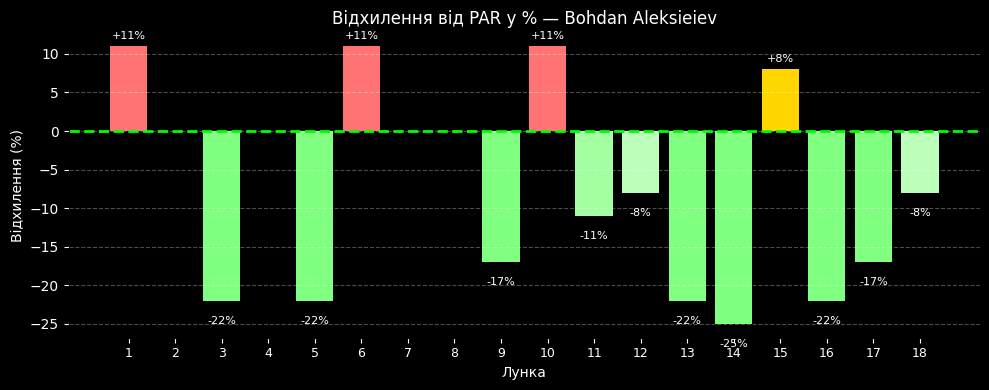

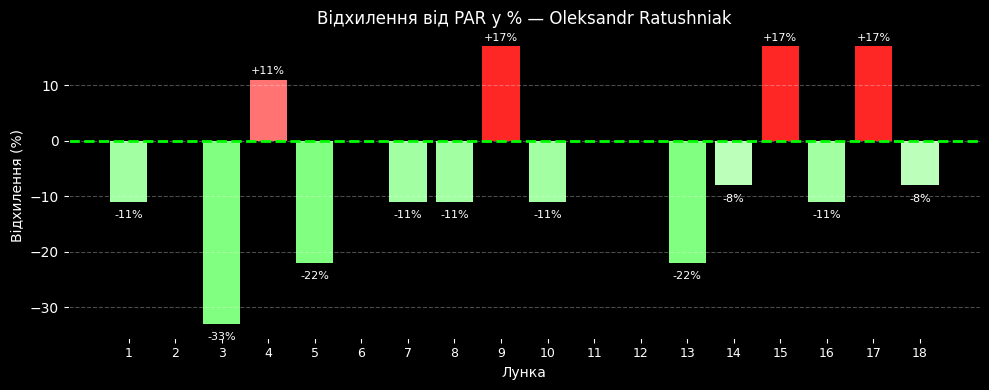

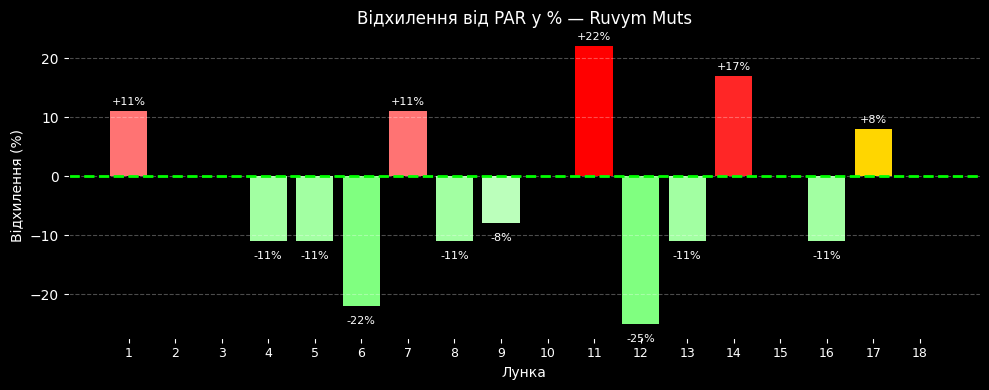

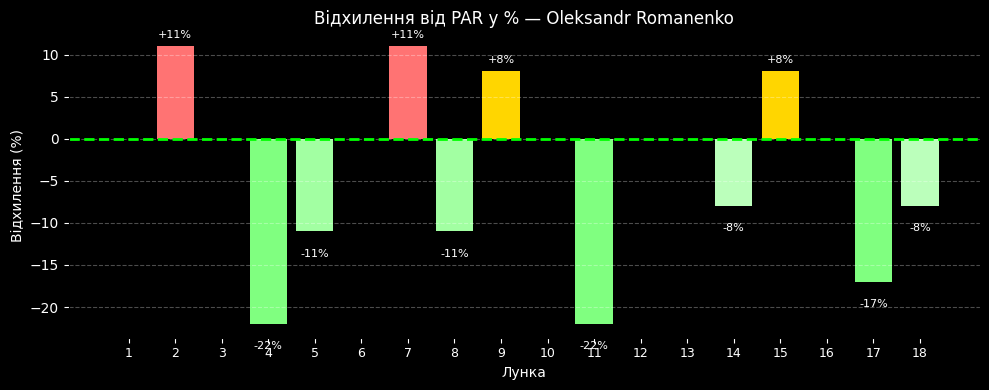

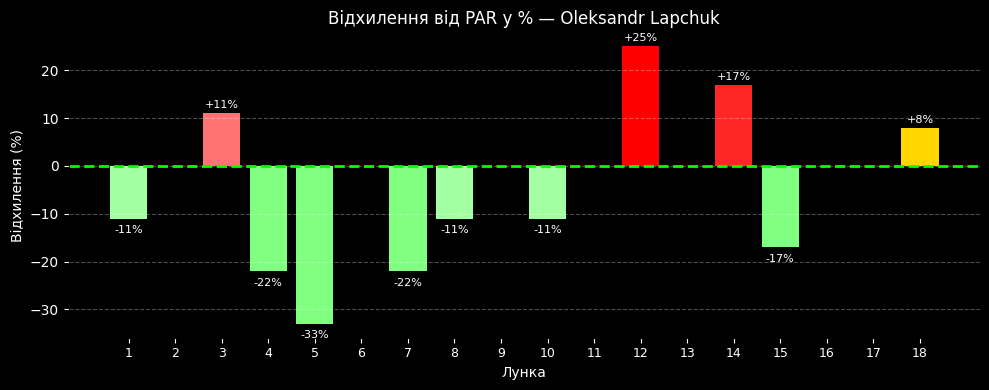

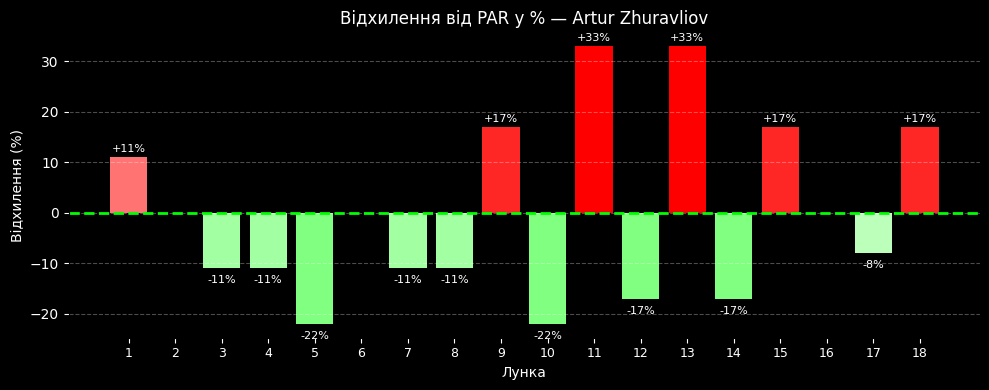

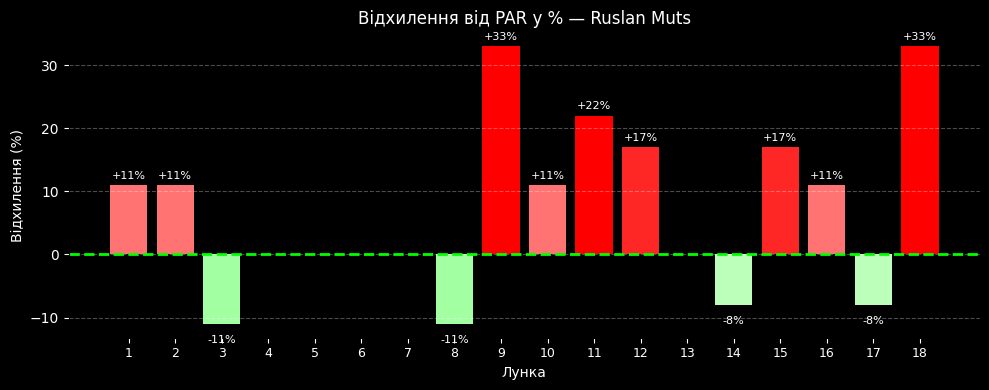

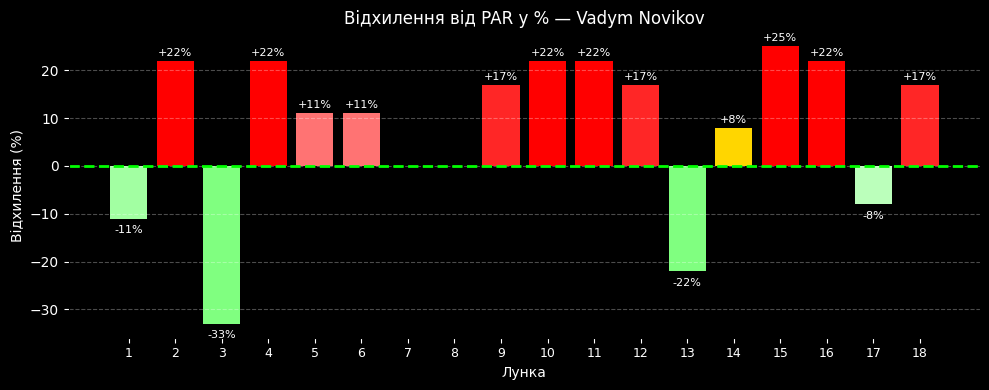

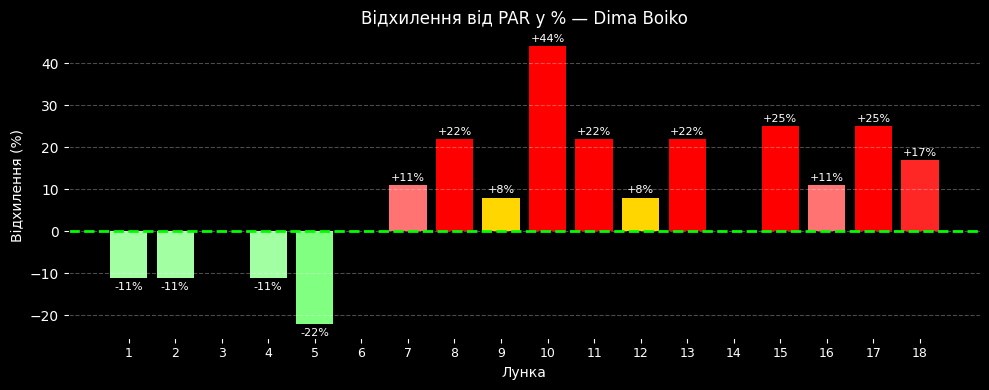

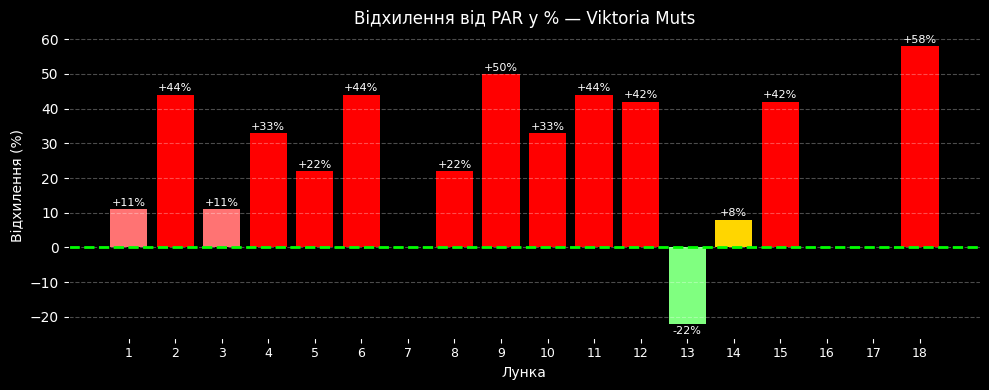

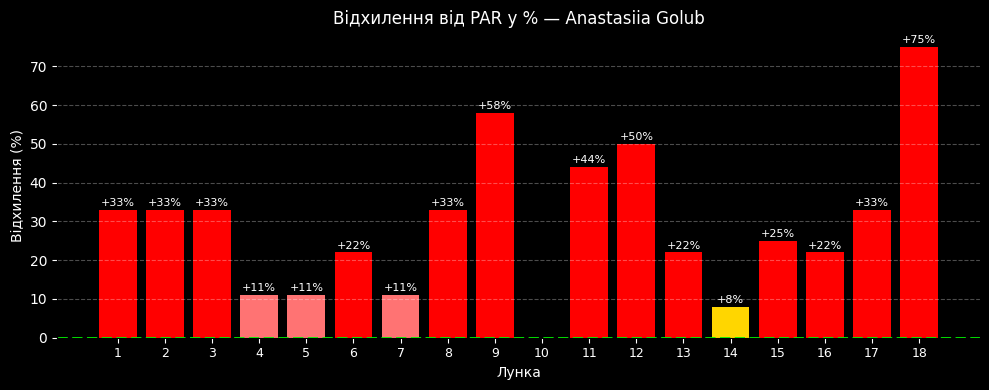

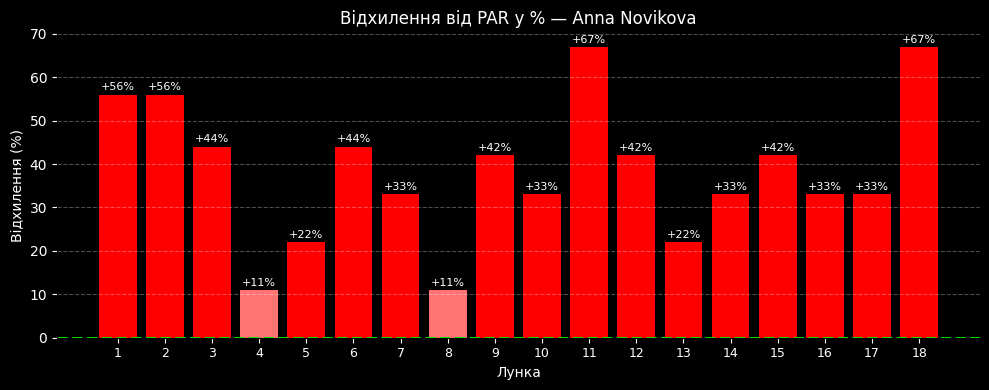

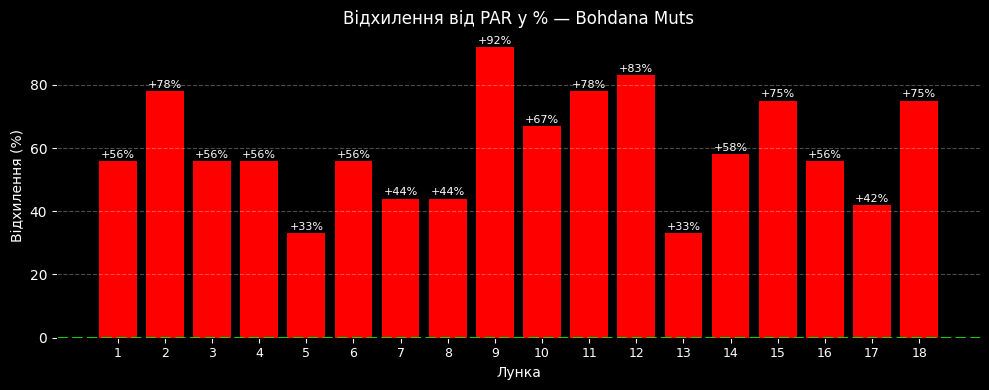

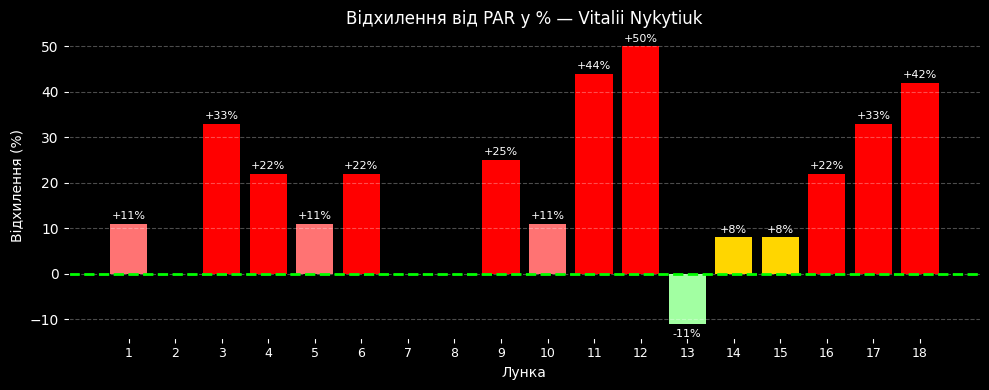

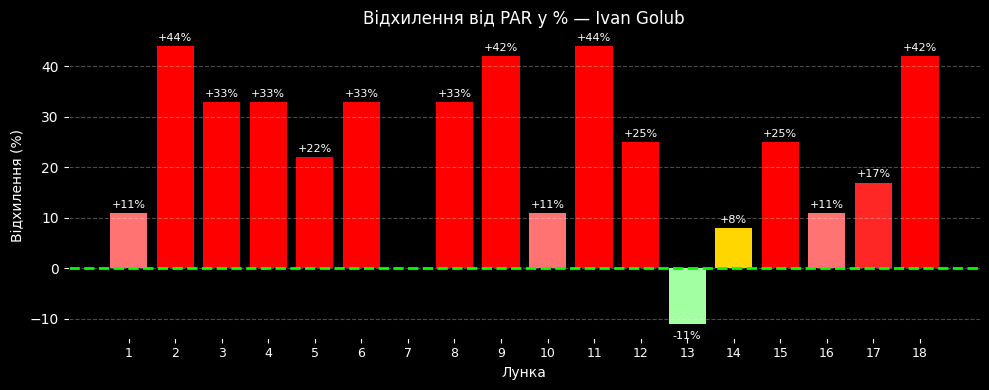

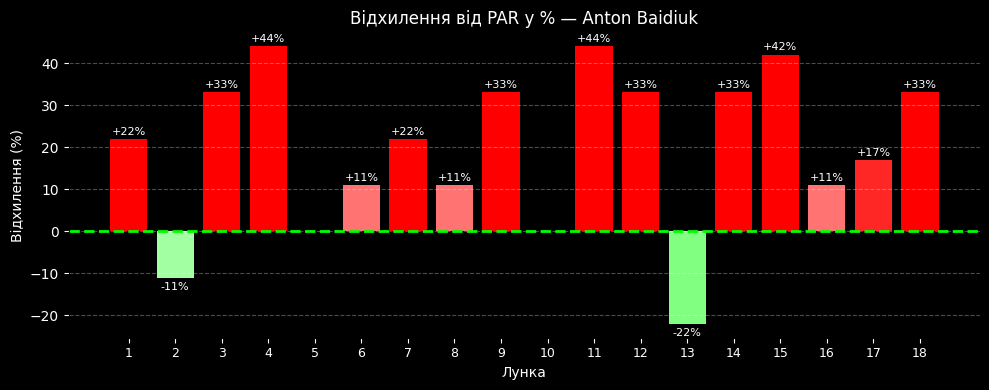

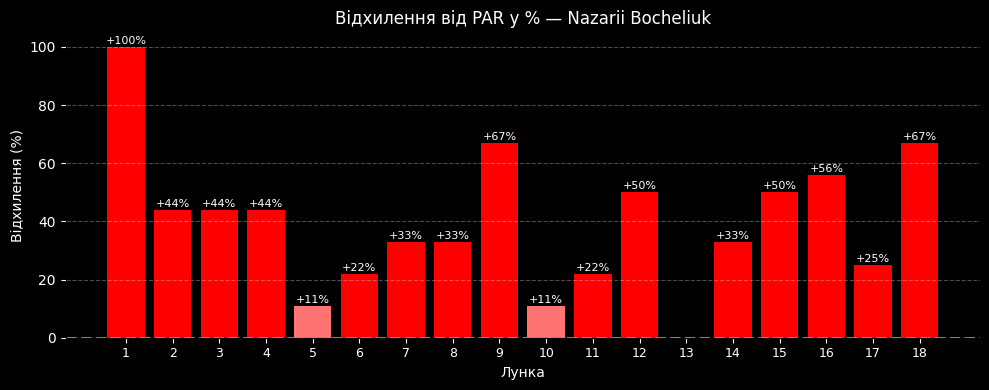

In [19]:
import os

# 🧮 Відхилення гравців у %
def get_player_percent_deviation(df, par_list, holes):
    players = df['Player'].unique()
    percent_dev = {}
    par_series = pd.Series(par_list, index=holes)

    for player in players:
        scores = df[df['Player'] == player][holes].astype(int)
        avg_scores = scores.mean()
        deviation = ((avg_scores - par_series) / par_series * 100).round(0)  # ⬅️ округлення до 0 знаків
        percent_dev[player] = deviation

    return pd.DataFrame(percent_dev).T


# 🎨 Колір для таблиці
def style_deviation_table(df):
    def color_cell(val):
        if pd.isna(val): return ''
        if val < 0:
            intensity = min(abs(val) / 15, 1)
            green = int(255 - intensity * 120)
            return f'background-color: rgb({green}, 255, {green}); color: black'
        elif val < 10:
            return 'background-color: gold; color: black'
        else:
            red_intensity = min(val / 20, 1)
            red = int(255 * red_intensity)
            return f'background-color: rgb(255, {255 - red}, {255 - red}); color: black'
    return df.round(1).style.applymap(color_cell)

# 🎨 Колір для графіка
def get_bar_color(val):
    if val < 0:
        intensity = min(abs(val) / 15, 1)
        green = 1.0  # максимально яскравий зелений
        red = (1 - intensity * 0.5)
        return (red, green, red)
    elif val < 10:
        return (1.0, 0.84, 0.0)  # gold
    else:
        red_intensity = min(val / 20, 1)
        green = 1.0 - red_intensity
        return (1.0, green, green)


def plot_player_deviation(player_percent_df, year, tournament, df):
    for player in player_percent_df.index:

        if pd.isna(player):
            continue

        scores = player_percent_df.loc[player].round(0)
        x = np.arange(len(scores))
        bar_colors = [get_bar_color(val) for val in scores.values]

        fig, ax = plt.subplots(figsize=(10, 4), facecolor='black')
        bars = ax.bar(x, scores.values, color=bar_colors)

        ax.axhline(0, color='lime', linestyle='--', linewidth=2)

        for i, val in enumerate(scores):
            if val == 0:
                continue
            offset = 1 if val > 0 else -3
            ax.text(i, val + offset, f'{val:+.0f}%', ha='center', color='white', fontsize=8)

        ax.set_xticks(x)
        ax.set_xticklabels(scores.index, color='white', fontsize=9)
        ax.set_title(f'Відхилення від PAR у % — {player}', color='white', fontsize=12)
        ax.set_ylabel('Відхилення (%)', color='white', fontsize=10)
        ax.set_xlabel('Лунка', color='white', fontsize=10)
        ax.tick_params(colors='white')
        ax.set_facecolor('black')
        fig.patch.set_facecolor('black')
        plt.grid(axis='y', linestyle='--', alpha=0.3, color='white')
        plt.tight_layout()

        player_rows = df[df['Player'] == player]
        if not player_rows.empty:
            division = player_rows['DIV'].iloc[0]
        else:
            division = "Unknown"

        folder_path = f"/content/drive/MyDrive/dg/{year}/{tournament}/{division}/{player}"
        os.makedirs(folder_path, exist_ok=True)
        file_path = os.path.join(folder_path, "percent.png")

        fig.savefig(file_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
        plt.show()  # ⬅️ Додати для відображення графіка
        plt.close(fig)


        fig.savefig(file_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
        plt.close(fig)



# 🚀 Запуск
player_percent_df = get_player_percent_deviation(df, par, holes)

display(HTML("<h3 style='color:#444;'>🎯 Відхилення гравців у % від par (забарвлена таблиця)</h3>"))
display(style_deviation_table(player_percent_df))

plot_player_deviation(player_percent_df, year, tournament, df)


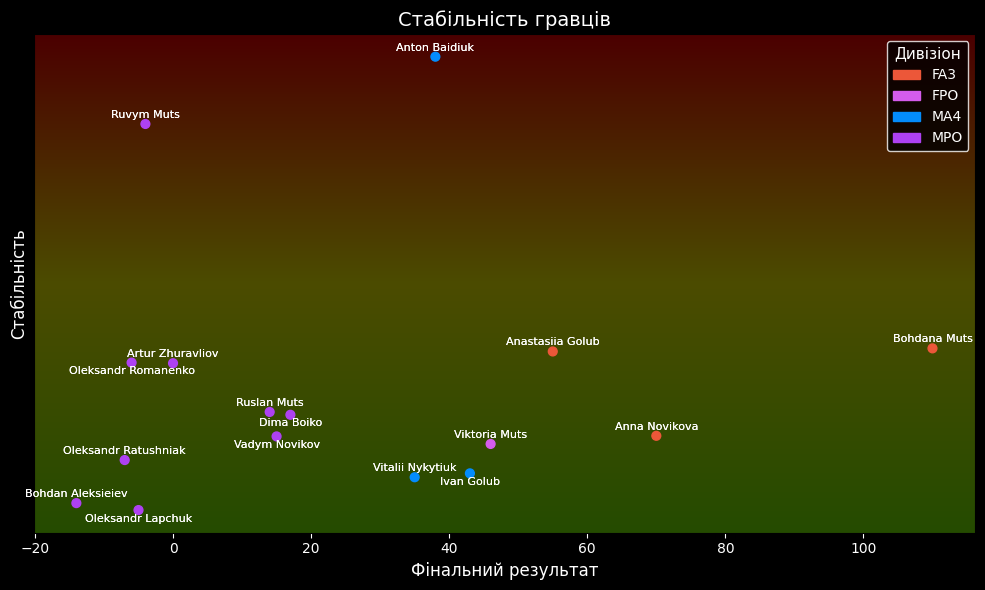

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.cm import ScalarMappable
# 🔢 Лунки
hole_cols = [str(i) for i in range(1, 19)]

# 📥 Очистка та підготовка
df = df[pd.to_numeric(df["Round"], errors="coerce").notna()].copy()
df["Round"] = df["Round"].astype(int)

# ✅ Перевірка наявності лунок
missing = [col for col in hole_cols if col not in df.columns]
if missing:
    print("❌ Відсутні колонки:", missing)
else:
    # 🔧 Преобразування лунок у числовий формат
    df[hole_cols] = df[hole_cols].apply(pd.to_numeric, errors='coerce')


# 🎨 Колірна карта
cmap = plt.get_cmap('viridis')  # або 'plasma', 'inferno', 'magma', 'cividis', 'coolwarm', 'Greens'


# 🔢 Лунки
hole_cols = [str(i) for i in range(1, 19)]

# 📊 Нестабільність за логарифмом
grouped = df.groupby("Player")[hole_cols]

def player_instability_log(scores):
    means = scores.mean()
    log_dev = np.log1p(np.abs(scores - means))
    deltas = log_dev.sum()

    count_below_1 = (deltas < 1).sum()
    total_instability = deltas.sum()
    count_times_555 = count_below_1 * 0.0555 if count_below_1 > 0 else None
    final_division = total_instability / count_times_555 if count_times_555 else None

    deltas["Instab / (×Count × 5.55)"] = final_division
    return deltas

instability_df = grouped.apply(player_instability_log).reset_index()

# 📊 Дані для графіка
players = df['Player'].unique()
metric_dict = dict(zip(instability_df["Player"], instability_df["Instab / (×Count × 5.55)"]))

# ⚙️ Параметри парів
par_sum = sum(par)  # ⚠️ переконайся, що список par існує і має 18 значень
ideal_total = par_sum * 3

plot_data = []

for player_name in players:
    rounds = df[df["Player"] == player_name].copy()

    try:
        total_sum = rounds["Tot"].sum()
        division = rounds["DIV"].iloc[0]
        metric_value = metric_dict.get(player_name)
        if metric_value is not None:
            x_value = total_sum - ideal_total  # 🔁 Відхилення від ідеального Tot
            plot_data.append((player_name, x_value, metric_value, division))
    except Exception:
        continue

# 🧹 Видалити точку з іменем "Michael Aaron"
plot_data = [entry for entry in plot_data if entry[0] != "Eduard Shalaiko"]


# 🎨 Побудова графіка
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('black')
ax.set_facecolor('none')

names, totals, metrics, divisions = zip(*plot_data)
colors = [division_colors.get(div, "#888888") for div in divisions]
ax.scatter(totals, metrics, c=colors, s=40)

# 🏷️ Імена над точками
# 🏷️ Імена над точками з індивідуальним зсувом



for name, x, y, _ in plot_data:
    # 🔧 Зсуви за іменами
    if name in [ "Oleksandr Lapchuk"]:
        y_offset = -13
        x_offset = 0
    elif name == "Oleksandr Romanenko":
        y_offset = -13
        x_offset = 0
    elif name == "Vadym Novikov":
        y_offset = -13
        x_offset = 0
    elif name == "Dima Boiko":
        y_offset = -13
        x_offset = 0
    elif name == "Ivan Golub":
        y_offset = -13
        x_offset = 0
    else:
        y_offset = 4
        x_offset = 0

    # 🏷️ Відображення тексту з урахуванням зсувів
    ax.text(x + x_offset, y + y_offset, name, fontsize=8, color='white', ha='center', va='bottom')


    ax.text(x + x_offset, y + y_offset, name, fontsize=8, color='white', ha='center', va='bottom')

# 📘 Легенда дивізіонів
unique_divisions = sorted(set(divisions))
legend_elements = [mpatches.Patch(color=division_colors.get(div, "#888888"), label=div) for div in unique_divisions]
legend = ax.legend(handles=legend_elements, title="Дивізіон", loc="upper right", fontsize=10,
                   title_fontsize=11, facecolor='black', edgecolor='white')
for text in legend.get_texts():
    text.set_color('white')
legend.get_title().set_color('white')

# 🧽 Прибрати y-вісь
ax.set_yticks([])

from matplotlib.colors import LinearSegmentedColormap

# 🌈 Кастомна колірна карта: салатовий → жовтий → червоний
custom_cmap = LinearSegmentedColormap.from_list("green_red_fade", ["#7CFC00", "#FFFF00", "#FF0000"])

# 🌈 Градієнтний фон осі Y
ax_limits = ax.get_ylim()
gradient = np.linspace(0, 1, 256).reshape(256, 1)
ax.imshow(gradient, extent=[ax.get_xlim()[0], ax.get_xlim()[1], ax_limits[0], ax_limits[1]],
          aspect='auto', cmap=custom_cmap, alpha=0.3, origin='lower', zorder=0)


# 📌 Фінальне оформлення
ax.set_xlabel("Фінальний результат", fontsize=12, color='white')
ax.set_title("Стабільність гравців", fontsize=14, color='white')
ax.tick_params(colors='white')
ax.grid(False)
ax.set_ylabel("Стабільність", fontsize=12, color='white')
plt.tight_layout()
plt.show()
# 📁 Папка для збереження
output_folder = f"/content/drive/MyDrive/dg/{year}/{tournament}/ALL"
os.makedirs(output_folder, exist_ok=True)

# 💾 Збереження графіка
file_path = os.path.join(output_folder, "stability.png")
fig.savefig(file_path, dpi=300, bbox_inches='tight', facecolor='black')
